### Objective
- Understand Variables, Missing Values, Duplicates, 5 number Summary, Optimize Datatypes. 
- Assess data quality to inform silver preprocessing pipeline.


#### Summary & Insights for Silver Pipeline
- 45 stores , 99 departments, 3 unique store types

- Negative Weekly_Sales(due to returns).
- Missing markdown values(ALL markdows) for data range between 2010-02-05 and 2011-11-04.
- CPI and Unemployment **both** missing between time period 2013-05-03 and
2013-07-26 
- There are patterns in missing data for markdowns, its missing at random (we simply did not had the markdowns recorded for the timeline).
- For last 3 months macroeconomic factors CPI and Unemployment both are missing. 
These values are probably missing because they fall into a recent/future time window where the government simply hasn't released the economic reports yet," the missingness is entirely dependent on observed data (the date). Therefore, it is MAR.
- Negative markdowns are present.
- Some weeks have heavy markdowns.

**Fixing Logic**
- Negative Weekly_Sales: we will clip to 0 because we want to predict demand not negative returns.
- Missing and Negative Markdowns: Fill and clip missing values with 0, simply denoting that promotional discount was zero.
- CPI and Unemployment missing: We forward fill with last available values, assuming that the change in these factors were minimal for the last three months.


#### Import necessary libraries

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from pathlib import Path
import sys

# Get the absolute path of the parent folder
parent_dir = str(Path().resolve().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)


In [18]:
import config
import pandas as pd
import missingno as msno
from deltalake import DeltaTable

#### Ingest
- csv's in data/raw

In [19]:
sales_df = DeltaTable(config.BRONZE_SALES_PATH).to_pandas()
features_df = DeltaTable(config.BRONZE_FEATURES_PATH).to_pandas()
stores_df = DeltaTable(config.BRONZE_STORES_PATH).to_pandas()

#### Rows (random samples)

In [20]:
sales_df.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday
71174,8,19,02/04/2010,1352.60,False
20369,2,98,24/06/2011,13580.33,False
143882,15,46,31/12/2010,13707.99,True
123205,13,42,07/01/2011,6399.04,False
211400,22,32,18/03/2011,5626.81,False


In [21]:
features_df.sample(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
5621,31,08/03/2013,52.76,3.658,20026.11,158.49,94.54,4008.08,6719.43,224.3427668,6.237,False
494,3,03/08/2012,86.55,3.417,5683.49,37.2,0.04,2484.22,639.29,225.4636332,6.334,False
4935,28,02/07/2010,91.98,3.105,NA,NA,NA,NA,NA,126.1392,14.18,False
7235,40,21/09/2012,54.12,4.056,3688.63,7.64,NA,693.23,4870.36,138.6534,4.156,False
5221,29,29/06/2012,70.99,3.577,5142.08,329.04,0.27,565.5,1957.42,138.1962667,9.14,False


In [22]:
stores_df.sample(5)

,Store,Type,Size
38,39,A,184109
34,35,B,103681
31,32,A,203007
22,23,B,114533
13,14,A,200898


#### Duplicates
- None found

In [23]:
sales_df[sales_df.duplicated()]

,Store,Dept,Date,Weekly_Sales,IsHoliday


In [24]:
features_df[features_df.duplicated()]

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday


In [25]:
stores_df[stores_df.duplicated()]

,Store,Type,Size


#### Count, Datatype's

In [26]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int32  
 1   Dept          421570 non-null  int32  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int32(2), object(1)
memory usage: 10.1+ MB


- Date is an object, convert to datetime

In [27]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int32  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     8190 non-null   object 
 5   MarkDown2     8190 non-null   object 
 6   MarkDown3     8190 non-null   object 
 7   MarkDown4     8190 non-null   object 
 8   MarkDown5     8190 non-null   object 
 9   CPI           8190 non-null   object 
 10  Unemployment  8190 non-null   object 
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(2), int32(1), object(8)
memory usage: 680.0+ KB


- Again Date is an object, convert to datetime
- MarkDown, CPI, Unemployment Features are being treated as object due to NA value present instead of null

In [28]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int32 
 1   Type    45 non-null     object
 2   Size    45 non-null     int32 
dtypes: int32(2), object(1)
memory usage: 852.0+ bytes


#### Data Type Conversion

In [29]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d/%m/%Y')
features_df['Date'] = pd.to_datetime(features_df['Date'], format='%d/%m/%Y')

In [30]:
cols_to_fix = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']
# apply() runs the function on each column individually
features_df[cols_to_fix] = features_df[cols_to_fix].apply(pd.to_numeric, errors='coerce')

#### Sorting by Date


In [185]:
sales_df = sales_df.sort_values(by='Date', ascending=True)
features_df = features_df.sort_values(by='Date', ascending=True)

#### Missing Values
- Missing markdown values(ALL markdows) for data range between 2010-02-05 and 2011-11-04
- CPI and Unemployment **both** missing between time period 2013-05-03 and
2013-07-26 
- There are patterns in missing data for markdowns, its missing at random (we simply did not had the markdowns recorded for the timeline).
- For last 3 months macroeconomic factors CPI and Unemployment both are missing. These values are probably missing because they fall into a recent/future time window where the government simply hasn't released the economic reports yet," the missingness is entirely dependent on observed data (the date). Therefore, it is MAR.


In [186]:
features_df.isna().mean() * 100

Store            0.000000
Date             0.000000
Temperature      0.000000
Fuel_Price       0.000000
MarkDown1       50.769231
MarkDown2       64.334554
MarkDown3       55.885226
MarkDown4       57.704518
MarkDown5       50.549451
CPI              7.142857
Unemployment     7.142857
IsHoliday        0.000000
dtype: float64

<Axes: >

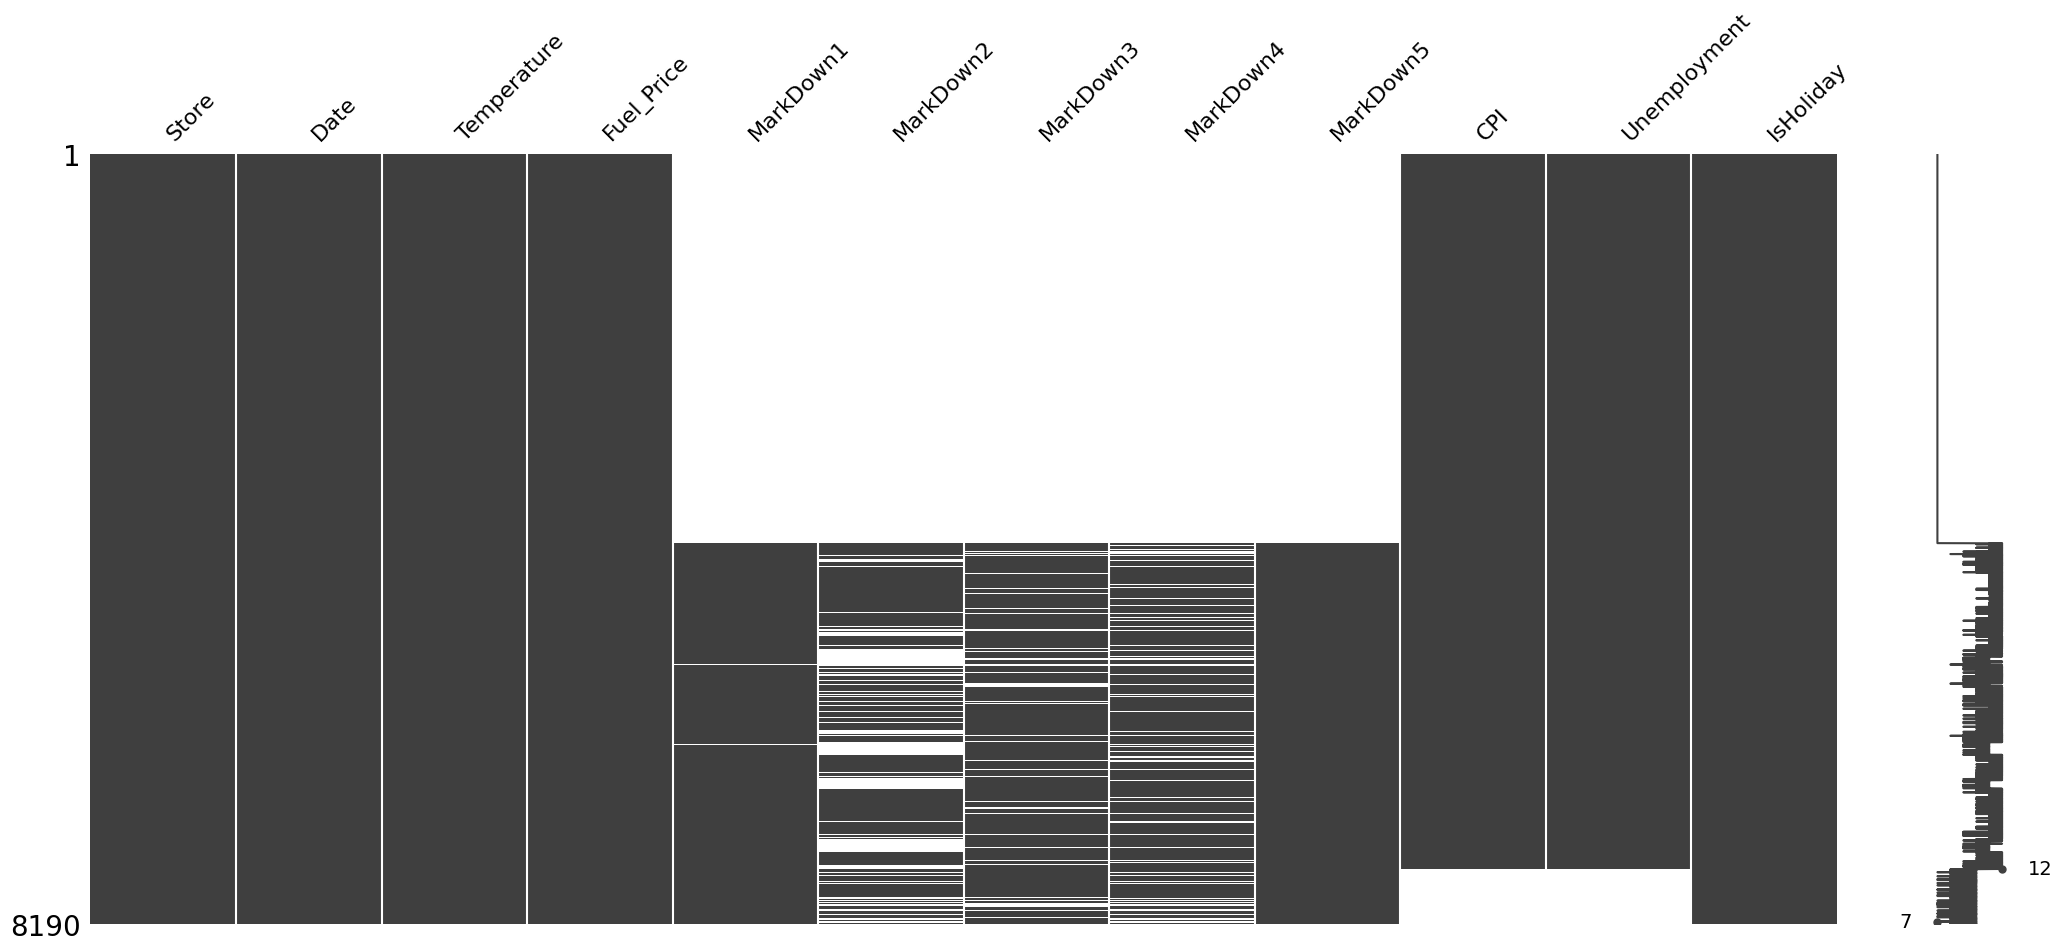

In [187]:
msno.matrix(features_df)

<Axes: >

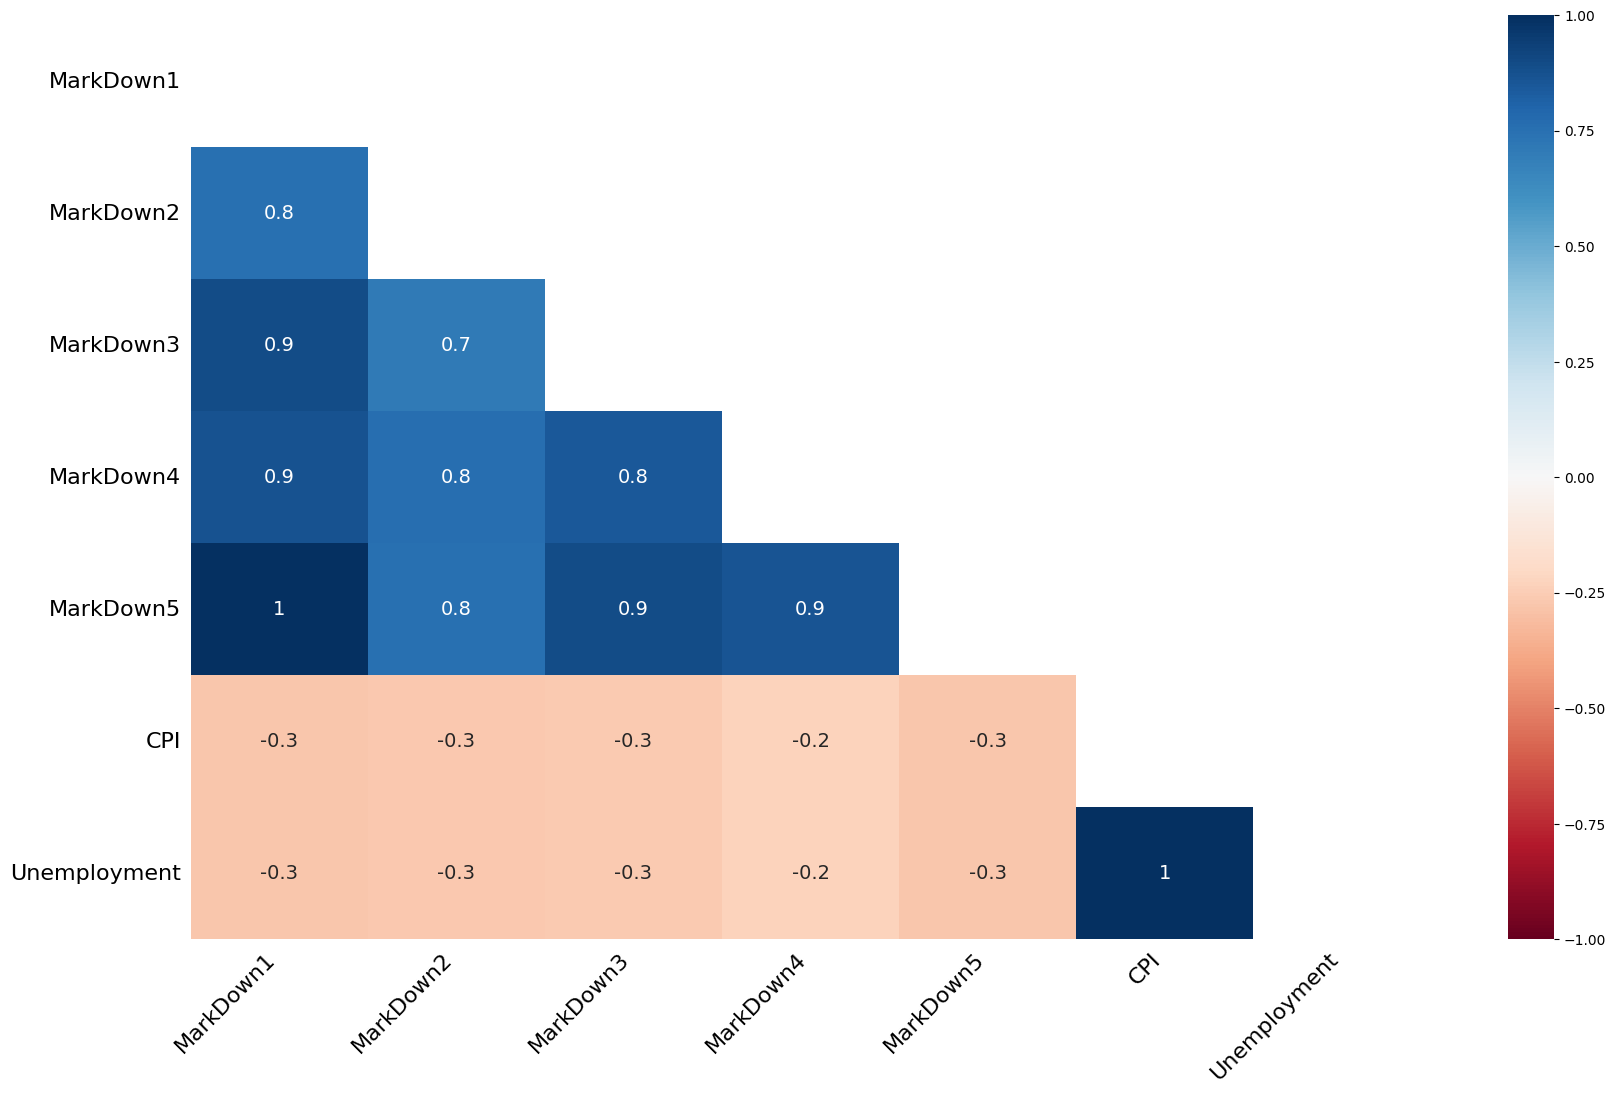

In [188]:
msno.heatmap(features_df)

<Axes: >

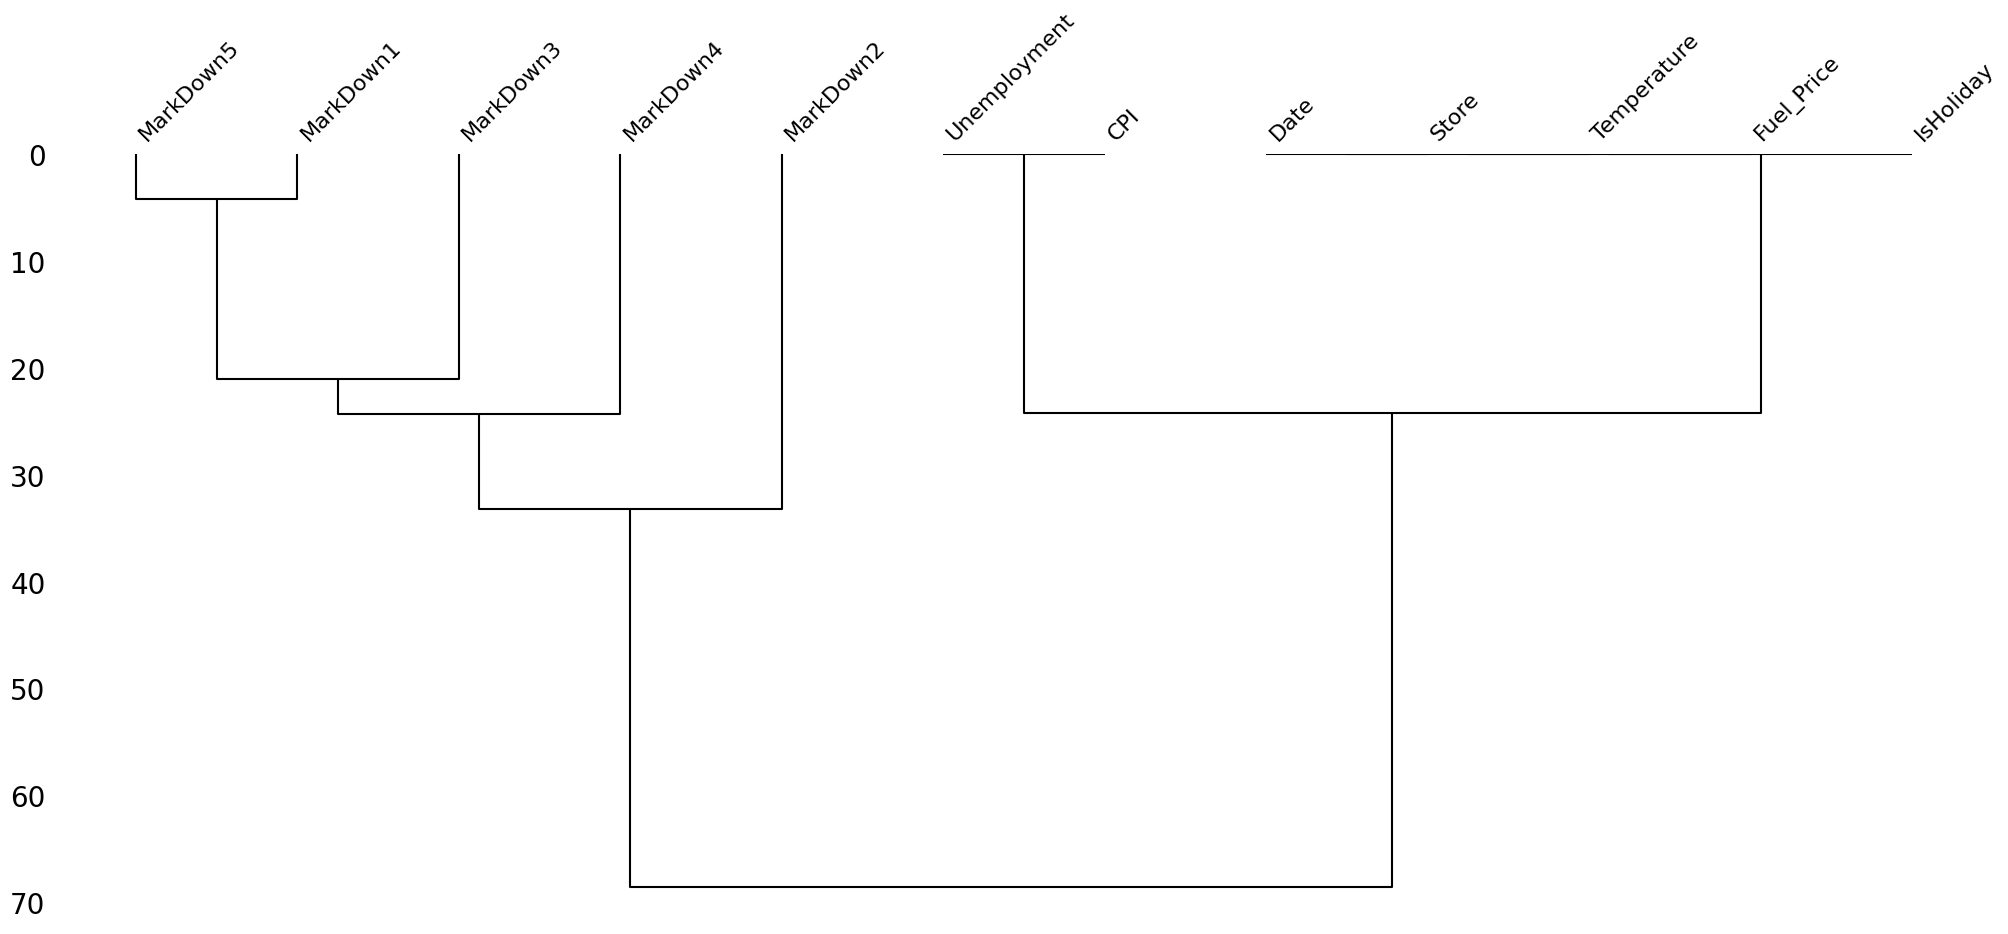

In [189]:
msno.dendrogram(features_df)

- We can see a pattern in markdown's for missing values, they are highly correlated.
- Similary, CPI and Unemployment are in sync for missing values. 

lets try to find the starting and ending date for which these markdowns are missing 

In [190]:
null_rows = features_df[features_df['MarkDown1'].isna() & 
                            features_df['MarkDown2'].isna() & 
                            features_df['MarkDown3'].isna() & 
                            features_df['MarkDown4'].isna() & 
                            features_df['MarkDown5'].isna() ]
print(null_rows['Date'].min())
print(null_rows['Date'].max())


2010-02-05 00:00:00
2011-11-04 00:00:00


In [191]:
null_cpi_unem = features_df[features_df['CPI'].isna() & features_df['Unemployment'].isna()]
null_cpi_unem.sample(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
3272,18,2013-07-05,77.15,3.643,8154.57,731.06,668.11,12012.13,2688.84,NaN,NaN,False
4000,22,2013-07-05,75.13,3.643,10445.17,2347.05,376.20,6679.54,859.63,NaN,NaN,False
7637,42,2013-06-14,91.98,3.771,10.63,NaN,8.24,NaN,1735.58,NaN,NaN,False
3821,21,2013-07-26,85.00,3.620,1025.38,928.07,4.00,97.85,2549.08,NaN,NaN,False
1629,9,2013-05-31,78.83,3.466,1573.24,65.11,203.57,5.84,1536.38,NaN,NaN,False


In [192]:
print(null_cpi_unem['Date'].min())
print(null_cpi_unem['Date'].max())

2013-05-03 00:00:00
2013-07-26 00:00:00


#### 5 number summary

- Negative Weekly_Sales (due to returns)
- Negative markdowns are present.
- Some weeks have heavy markdowns.


In [193]:
features_df.describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,2011-10-31 12:00:00,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
min,1.000000,2010-02-05 00:00:00,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,2010-12-17 00:00:00,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,2011-10-31 12:00:00,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,2012-09-14 00:00:00,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,2013-07-26 00:00:00,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000
std,12.987966,NaN,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259


In [194]:
sales_df['IsHoliday'].sum()

np.int64(29661)

In [195]:
sales_df.describe()

,Store,Dept,Date,Weekly_Sales
count,421570.000000,421570.000000,421570,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375360,15981.258123
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000
std,12.785297,30.492054,NaN,22711.183519


In [196]:
stores_df.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [197]:
stores_df.describe(include='object')

,Type
count,45
unique,3
top,A
freq,22


#### Handling Quality Issues (Informing the Silver Pipeline)

- We dont need returns in our dataset, we want to predict demand.

In [198]:
sales_df['Weekly_Sales'] = sales_df['Weekly_Sales'].clip(lower=0.0)

- We will fill the markdown's simply with 0 , denoting no promotional discount.
- We will also handle negative markdown which is a data error, by clipping them to 0

In [199]:
features_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] = features_df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].fillna(0.0).clip(lower=0)

- For `CPI` and `Unemployment` best would be to use forward fill assuming the factors remained same for the last months.

In [200]:
features_df[['CPI', 'Unemployment']] = features_df[['CPI', 'Unemployment']].ffill()